In [1]:
# function to solve B using non-negative least squares
from scipy.optimize import nnls
%cd ..
from compiler_options import compiler_decorator
from myutils import khatri_rao_power, khatri_rao_product, \
     option_parser, compiler_decorator, prange, pos, isbool, \
    dormqr, lapack, norm

from part_sym_SPM import spm_21sym

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.linalg import svd

import numpy as np
# the output of this cell is covid_T.npy
import anndata as ad
from sklearn.decomposition import PCA
import pandas as pd


def nnls_refine_B(T, A):
    """
    Refine B matrix using non-negative least squares.
    
    Parameters:
    -----------
    T : numpy.ndarray
        Original tensor (m × m × n)
    A : numpy.ndarray  
        A matrix from decomposition (m × r)
        
    Returns:
    --------
    B_nnls : numpy.ndarray
        Non-negative refined B matrix
    """
    m, _, n = T.shape
    r = A.shape[1]
    
    # Reshape tensor for matrix operations
    T_mat = T.reshape(m, -1)  # m × (m*n)
    
    # Compute Khatri-Rao product A ⊙ A
    A_kr = khatri_rao_power(A, 2)  # (m²) × r
    
    B_nnls = np.zeros((n, r))
    residual_list = []
    # Solve for each context (row of B) separately
    for i in range(n):
        # Extract the i-th slice: T[:,:,i]
        T_slice = T[:, :, i].flatten()  # Flatten to vector of length m²
        
        # Solve non-negative least squares: min ||A_kr * b_i - T_slice||²
        # subject to b_i >= 0
        b_i, residual = nnls(A_kr, T_slice)
        residual_list.append(residual)
        B_nnls[i, :] = b_i

    return B_nnls,residual_list

# A, B = spm_21sym(T_500,r)
# B_nnls, residual_list = nnls_refine_B(T_500.copy(), A)

/ewsc/exxact04/sbhate/mcpc/covid_code


In [2]:
import anndata as ad
from sklearn.decomposition import PCA
import pandas as pd
lung_atlas = ad.read_h5ad('/data/sbhate/mcpc/spm-private/downstream/luca.h5ad')

In [3]:
donor_ct_counts = pd.crosstab(lung_atlas.obs['donor_id'],lung_atlas.obs['ann_fine'])
good_donors = donor_ct_counts.index[donor_ct_counts['Cancer cells']>200]
patient_data = lung_atlas.obs[['donor_id', 'uicc_stage']].drop_duplicates().set_index('donor_id')
display(patient_data.loc[good_donors]['uicc_stage'].value_counts())
ct = 'Cancer cells'
var_genes = lung_atlas.var.index[(lung_atlas.var['mito']==False)]
x_sub = lung_atlas[lung_atlas.obs[lung_atlas.obs['donor_id'].isin(good_donors) & (lung_atlas.obs['ann_fine']==ct) & (lung_atlas.obs['disease'].isin(['lung adenocarcinoma']))].index, var_genes].to_df()


uicc_stage
III or IV     21
I             19
IV            19
II            12
III           11
non-cancer     0
Name: count, dtype: int64

In [4]:
pca = PCA(n_components=400, random_state=418)
X_pc = pd.DataFrame(pca.fit_transform(x_sub),index = x_sub.index)
# X_pc = x_sub
covs = X_pc.groupby(lung_atlas.obs['donor_id'].astype(str).loc[X_pc.index]).apply(lambda w : np.cov(w.T))
means = X_pc.groupby(lung_atlas.obs['donor_id'].astype(str).loc[X_pc.index]).apply(lambda w : np.mean(w,axis=0))
stds = X_pc.groupby(lung_atlas.obs['donor_id'].astype(str).loc[X_pc.index]).apply(lambda w : np.std(w,axis=0))
T_500 = np.stack(covs,axis = 2)

In [5]:
r = 5
np.random.seed(13)
A, B = spm_21sym(T_500,r)
B_nnls, residual_list= nnls_refine_B(T_500.copy(), A)



In [10]:
gene_loadings_A = pd.DataFrame(A.T@pca.components_, columns = lung_atlas.var['feature_name'])

Anload = gene_loadings_A.loc[:,(~gene_loadings_A.columns.str.contains(r'LOC|MIR|MT|-NCRNA|RPL|^\d+')) & ( (lung_atlas.var['feature_type']=='protein_coding').values)]




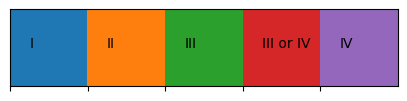

In [6]:
stages = patient_data.loc[good_donors]['uicc_stage']
color_map = {i:np.array(j) for i,j in zip(sorted(stages.unique()), sns.color_palette('tab10',5))}

sns.palplot(sns.color_palette('tab10',5))
for i,j in enumerate(color_map.keys()):
    plt.text(i-0.25,0, j)

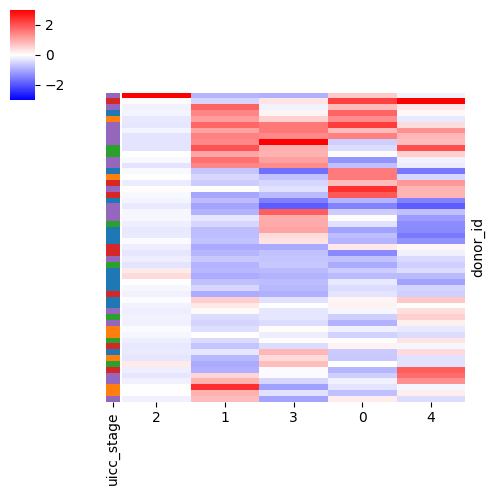

In [7]:
out = pd.DataFrame(B_nnls,index = covs.keys())
g = sns.clustermap(out,cmap = 'bwr',vmin = -3, vmax = 3,z_score =1,yticklabels=False,figsize =( 5,5),xticklabels=True,row_colors = stages.astype(str).map(color_map))
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

In [8]:
from scipy.stats import spearmanr,ttest_ind,pearsonr
def print_stats(out):
    outs = {}
    for i in range(len(out.columns)):

        y = stages.loc[out.index]
        r1,p1 = spearmanr(y.cat.codes.astype(int), out[i])
        if p1<0.05:
            print('spearman', i, r1,p1 )

        

        q = y.isin(['III or IV', 'IV'])
        r,p = ttest_ind(out[i].values[q], out[i].values[~q])
        if p<0.05:
            print('class', i, r,p)
        outs[i] = [r1,p1,r,p]
    return pd.DataFrame(outs).T


Text(0, 0.5, 'Component 4')

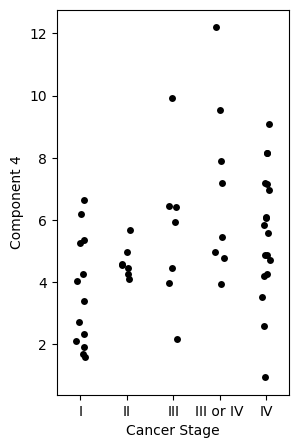

In [9]:
plt.figure(figsize = (3,5))
sns.stripplot(pd.concat([out[4], stages.loc[out.index]],axis=1), x = 'uicc_stage', y = 4, order = ['I','II','III','III or IV','IV'], c= 'black')

plt.xlabel('Cancer Stage')
plt.ylabel('Component 4')

In [89]:
mets = lung_atlas.obs.groupby('donor_id').apply(lambda w: w['origin'].value_counts(normalize = True)).unstack().loc[out.index]['tumor_metastasis']

/tmp/ipykernel_974879/3324333511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mets = lung_atlas.obs.groupby('donor_id').apply(lambda w: w['origin'].value_counts(normalize = True)).unstack().loc[out.index]['tumor_metastasis']
/tmp/ipykernel_974879/3324333511.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mets = lung_atlas.obs.groupby('donor_id').apply(lambda w: w['origin'].value_counts(normalize = True)).unstack().loc[out.index]['tumor_metastasis']


In [92]:
ttest_ind(out[4][mets>=0.6], out[4][mets<=0.4])

TtestResult(statistic=np.float64(0.792370409815052), pvalue=np.float64(0.4318882955660416), df=np.float64(50.0))

/tmp/ipykernel_974879/2017443859.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.scatter(out[4],lung_atlas.obs.groupby('donor_id').apply(lambda w: w['origin'].value_counts(normalize = True)).unstack().loc[out.index]['tumor_metastasis'], c = 'black')
/tmp/ipykernel_974879/2017443859.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plt.scatter(out[4],lung_atlas.obs.groupby('donor_id').apply(lambda w: w['origin'].value_counts(normalize = True)).unstack().loc[out.index]['tumor_metastasis'], c = 'black

Text(0, 0.5, 'percentage of cells from metastasis')

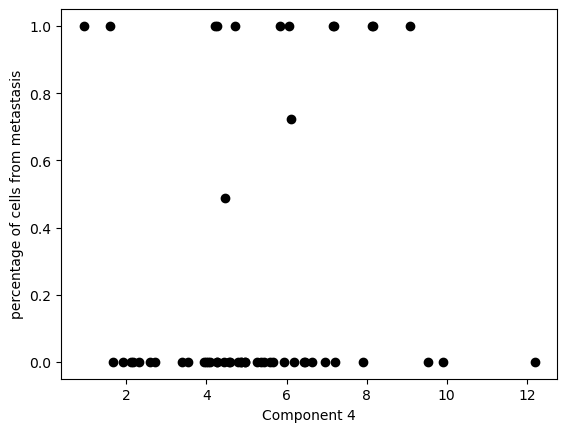

In [ ]:
plt.scatter(out[4],lung_atlas.obs.groupby('donor_id').apply(lambda w: w['origin'].value_counts(normalize = True)).unstack().loc[out.index]['tumor_metastasis'], c = 'black')
plt.xlabel('Component 4')
plt.ylabel('percentage of cells from metastasis')


Text(0, 0.5, 'Component 4')

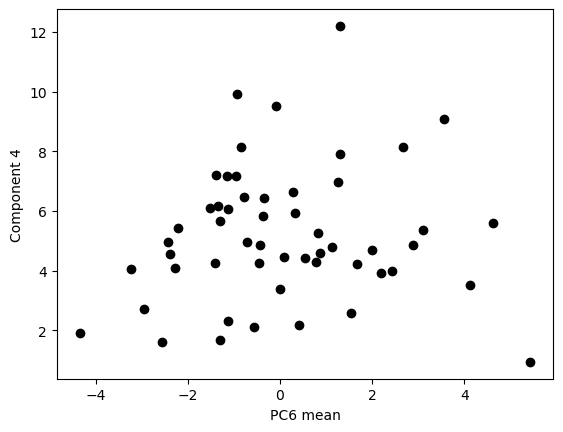

In [75]:
plt.scatter(means[6], out[4], c = 'black')
plt.xlabel('PC6 mean')
plt.ylabel('Component 4')


Text(0.5, 0, 'PC')

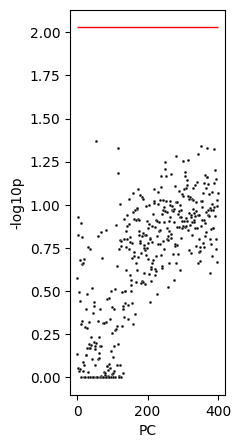

In [170]:
plt.figure(figsize = (2,5))
sns.scatterplot(-np.log10(ps), c = 'black', s = 4)
plt.hlines(-np.log10(ps_o[4]),0,400, colors = 'red', linewidths = 1)
plt.ylabel('-log10p')
# plt.legend()
plt.xlabel('PC')


In [19]:
print_stats(stds)

spearman 2 0.33507661577241715 0.014183398781169134
class 4 2.0589898321005786 0.04461942870031906
spearman 11 -0.2855913224978669 0.03817700288807406
spearman 15 0.30377893659456867 0.027011168783621368
spearman 53 0.31168659489748246 0.023090977781188377
class 53 2.081145414996954 0.042460100001599006
spearman 115 0.27502003192449787 0.046256056908750495
class 115 2.034783818361191 0.047087012483370855
spearman 117 0.31439184642216356 0.021865036153701552
spearman 147 0.29428974663107205 0.03243639773864412
spearman 160 0.31243574147354797 0.022745825178138432
spearman 171 0.28251149768515305 0.04040044139418006
spearman 178 0.30140663910369453 0.028290597532421295
spearman 187 0.2865069460908359 0.037535793085990504
spearman 228 0.27123267978994436 0.0494702055601296
spearman 231 0.2759772747716927 0.04547128857229094
spearman 243 0.28463407965067206 0.03885699181843455
spearman 249 0.2934989808007807 0.032926712091125035
spearman 252 0.2733136425012375 0.047682414679158534
spearman

In [ ]:
print_stats(means.iloc[:,:20])

class 2 -2.3813093227560787 0.021022025249225414
spearman 3 -0.4210203757488227 0.001693464410668302
class 3 -3.1582246988244935 0.0026667719101859714
class 5 2.1206394472491263 0.03883601047033845
spearman 6 0.47108833858253496 0.00037052258445947753
class 6 3.420723083187542 0.0012375465834289963
class 10 -2.167918296544965 0.03485577002891054


In [135]:
from scipy.spatial.distance import cdist

In [217]:
import statsmodels.api as sm

X = pd.concat([out.iloc[:,[4]], means.iloc[:,[3,6]]],axis=1)
# Add a constant term (intercept) to X
X_with_const = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(stages.loc[X.index].isin(['III','III or IV', 'IV']), X_with_const)
result = model.fit()

# View the results
display(result.summary())

Optimization terminated successfully.
         Current function value: 0.383420
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             uicc_stage   No. Observations:                   53
Model:                          Logit   Df Residuals:                       49
Method:                           MLE   Df Model:                            3
Date:                Tue, 09 Dec 2025   Pseudo R-squ.:                  0.4215
Time:                        12:03:32   Log-Likelihood:                -20.321
converged:                       True   LL-Null:                       -35.126
Covariance Type:            nonrobust   LLR p-value:                 1.667e-06
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2096      1.314     -1.681      0.093      -4.786       0.366
4              0.6400      0.258      2.479      0.013       0.134       1.146
3             -0.5221      0.261     -1.998      0.046      -1.034      -0.010
6              0.7313      0.279      2.624      0.009       0.185       1.278
==============================================================================
"""

In [82]:
gene_loadings_A = pd.DataFrame(A.T@pca.components_, columns = lung_atlas.var['feature_name'])

Anload = gene_loadings_A.loc[:,(~gene_loadings_A.columns.str.contains(r'LOC|MIR|MT|-NCRNA|RPL|^\d+')) & ( (lung_atlas.var['feature_type']=='protein_coding').values)]




In [113]:
dat = pd.concat([(X_pc@np.linalg.pinv(A).T)[4],lung_atlas.obs[['uicc_stage','donor_id']]],axis=1).dropna()
dat['donor_id'] = dat['donor_id'].astype(str)


/tmp/ipykernel_1461713/1892176784.py:1: UserWarning: 
The palette list has fewer values (1) than needed (13) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data = dat[dat['uicc_stage']=='I'], x = 'uicc_stage', y = 4, hue = 'donor_id', legend = False,dodge = True,order = ['I'],palette = ['grey'])


(-15.0, 15.0)

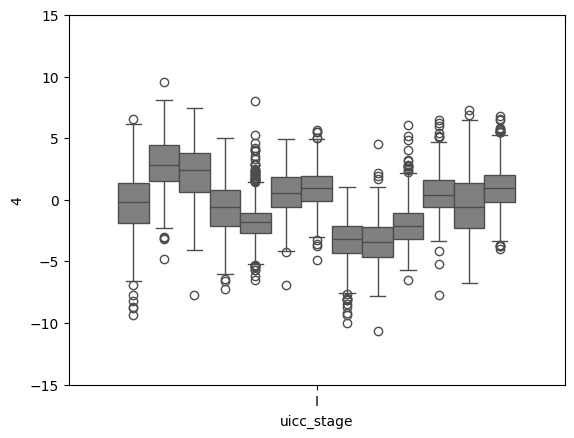

In [219]:
sns.boxplot(data = dat[dat['uicc_stage']=='I'], x = 'uicc_stage', y = 4, hue = 'donor_id', legend = False,dodge = True,order = ['I'],palette = ['grey'])
plt.ylim(-15,15)

In [224]:
from scipy.stats import ttest_ind

In [234]:
mcpc_mean = dat.groupby('donor_id')[4].std()

In [235]:
ttest_ind(mcpc_mean[stages=='IV'].dropna(),mcpc_mean[stages=='I'].dropna())

TtestResult(statistic=np.float64(2.484860281738983), pvalue=np.float64(0.01897682597989484), df=np.float64(29.0))

In [225]:
ttest_ind(dat[4][dat['uicc_stage']=='IV'],dat[4][dat['uicc_stage']=='I'])

TtestResult(statistic=np.float64(24.75280855788682), pvalue=np.float64(1.2134656076059612e-133), df=np.float64(24790.0))

/tmp/ipykernel_1461713/2525155449.py:2: UserWarning: 
The palette list has fewer values (1) than needed (13) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data = dat[dat['uicc_stage'].isin(['I'])],  y = 4, x = 'uicc_stage', legend = False,order = ['I'], hue = 'donor_id', palette = ['lightgrey'])


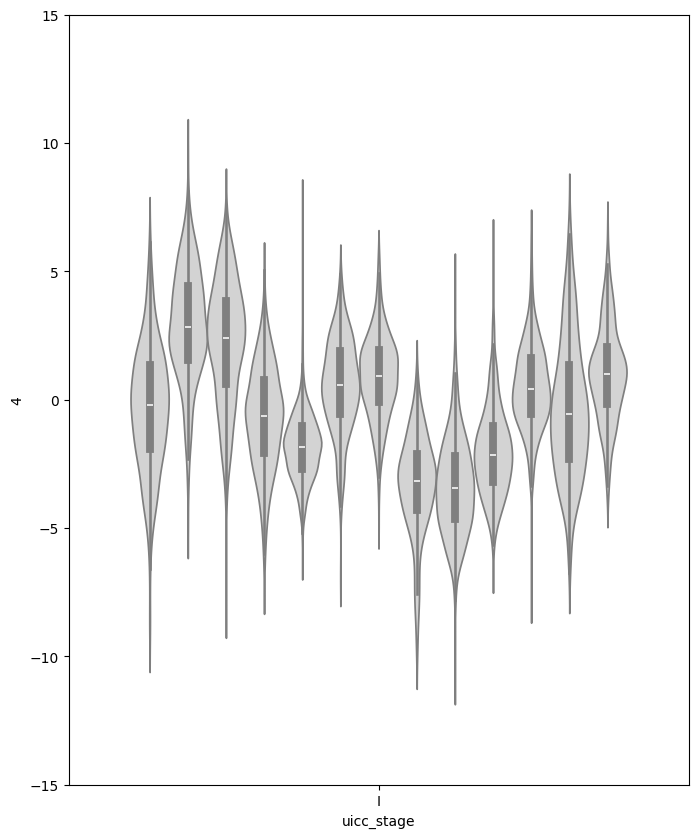

/tmp/ipykernel_1461713/2525155449.py:6: UserWarning: 
The palette list has fewer values (1) than needed (18) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data = dat[dat['uicc_stage'].isin(['IV'])],  y = 4, x = 'uicc_stage', legend = False,order = ['IV'], hue = 'donor_id', palette = ['darkgrey'])


(-15.0, 15.0)

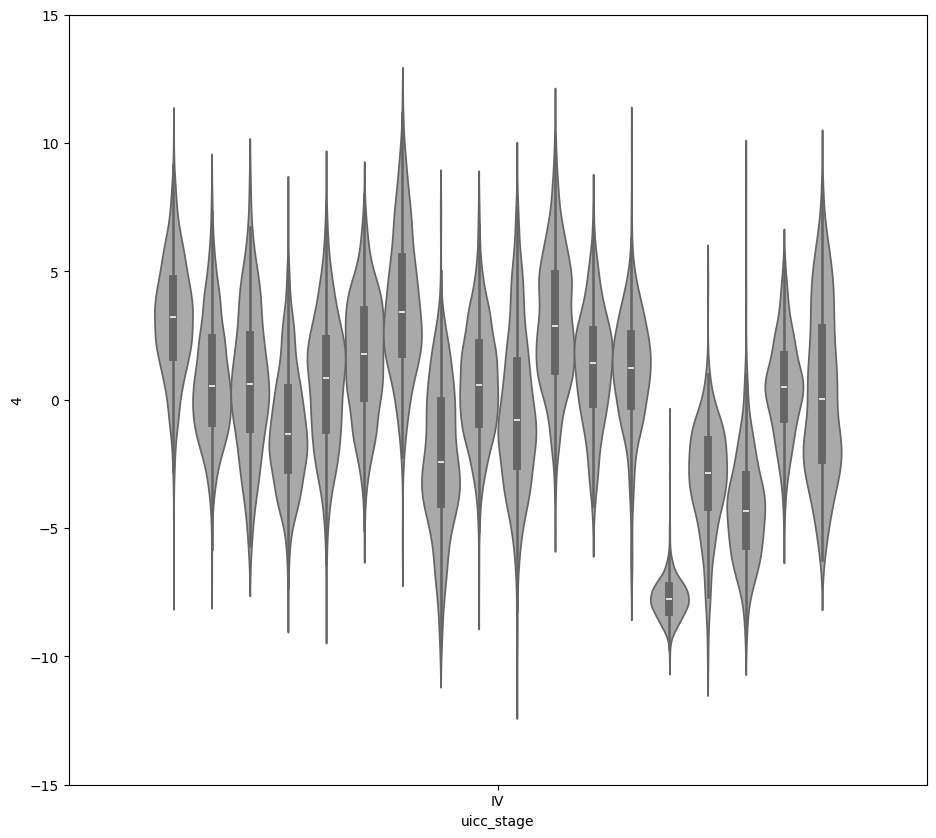

In [ ]:

plt.figure(figsize = (8,10))
sns.violinplot(data = dat[dat['uicc_stage'].isin(['I'])],  y = 4, x = 'uicc_stage', legend = False,order = ['I'], hue = 'donor_id', palette = ['lightgrey'])
plt.ylim(-15,15)
plt.show()
plt.figure(figsize = (18*8/13,10))
sns.violinplot(data = dat[dat['uicc_stage'].isin(['IV'])],  y = 4, x = 'uicc_stage', legend = False,order = ['IV'], hue = 'donor_id', palette = ['darkgrey'])
plt.ylim(-15,15)

In [11]:
import time
import gseapy as gp
libraries = [a for a in gp.get_library_name() if ('MSigDB_Hallmark' in a )or  ('Marker_2024' in a) or ('Process_2025' in a)]

def get_genes(nload, key,N = 50):
    a = nload.loc[key].sort_values()
    return a.index[:N],a.index[-N:]

Agsea = {}
for i in [4]:
    time.sleep(0.5)
    for gl,ud in zip(get_genes(Anload,i,200), ['bot','top']):
        for lib in libraries:
            enr = gp.enrichr(gene_list=list(gl),
                            gene_sets=lib,
                            cutoff=1, # P-value cutoff for significance
                            no_plot=True) # Set to True to suppress plotting

            # print('\n'.join(p_bot))
            Agsea[lib,i,ud] = enr.results.copy()
Abb = pd.concat(Agsea)

In [17]:
print(Abb[Abb['Adjusted P-value'] < 0.001].to_csv(sep= '\t'))

				Gene_set	Term	Overlap	P-value	Adjusted P-value	Old P-value	Old Adjusted P-value	Odds Ratio	Combined Score	Genes
CellMarker_2024	4	bot	0	CellMarker_2024	Plasma Cell Nasopharynx Human	25/69	6.051404397814663e-33	3.261706970422103e-30	0	0	64.14285714285714	4758.438991947317	CD63;TMED10;RPN2;GSTP1;IFI6;HSP90B1;MYDGF;LGALS1;PRDX4;SEC61G;CD59;TIMP1;TMED9;SSR4;HLA-C;PDIA6;PDIA4;SPCS1;IFI27;NPC2;SUB1;KDELR2;TMBIM6;P4HB;PPIB
CellMarker_2024	4	bot	1	CellMarker_2024	Migration Phase Fetal Germ Cell Fetal Gonad Human	27/165	3.648221090767008e-25	9.831955839617085e-23	0	0	22.2364915807992	1251.2560011931516	IFITM3;JPT1;COX7B;MGST3;GSTP1;MGST1;COX7A2;TXN;ATP5MC1;PSMB6;LGALS1;SNRPD2;PSMB3;TMSB4X;TSPO;TMSB10;CTSC;POLR2L;COX8A;H2AZ1;NQO1;VAMP8;MYL6;NDUFS5;RPA3;SNRPE;SLIRP
CellMarker_2024	4	bot	2	CellMarker_2024	Monocyte Fetal Kidney Human	46/796	1.5651475285084362e-22	2.8120483928868243e-20	0	0	7.587012987012987	380.93551535572334	CD63;COX7B;SERPINA1;TXN;COX5B;COX5A;CST3;LGALS3;LGALS1;TSPO;SH3BGRL3;

In [ ]:
Abb.loc['GO_Biological_Process_2025',4,'bot'].set_index('Term').filter(regex = 'Positive Apoptosis', axis =0)

/tmp/ipykernel_1461713/2837043600.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  Abb.loc['GO_Biological_Process_2025',4,'bot'].set_index('Term').filter(regex = 'Apoptosis', axis =0)


,Gene_set,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
Term,,,,,,,,,


In [211]:
Abb.loc['GO_Biological_Process_2025',4,'bot'].set_index('Term').filter(regex = 'Regulation of Apoptotic Process', axis =0)

/tmp/ipykernel_1461713/1645558853.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  Abb.loc['GO_Biological_Process_2025',4,'bot'].set_index('Term').filter(regex = 'Regulation of Apoptotic Process', axis =0)


,Gene_set,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
Term,,,,,,,,,
Regulation of Apoptotic Process (GO:0042981),GO_Biological_Process_2025,23/704,6.454950e-07,0.000046,0,0,3.648150,51.997981,ITGB1;CD74;HSP90AA1;ANXA1;GSTP1;IFI6;PARK7;HMG...
Negative Regulation of Apoptotic Process (GO:0043066),GO_Biological_Process_2025,16/475,2.460448e-05,0.001027,0,0,3.664109,38.885659,ITGB1;CD74;ANXA1;GSTP1;IFI6;PARK7;HSP90B1;SOD1...
Positive Regulation of Apoptotic Process (GO:0043065),GO_Biological_Process_2025,6/313,9.493632e-02,0.220658,0,0,1.963766,4.623784,ITGB1;LGALS3;LGALS1;ARL6IP5;HMGB1;SOD1


In [210]:
Abb.loc['GO_Biological_Process_2025',4,'top'].set_index('Term').filter(regex = 'Regulation of Apoptotic Process', axis =0)

/tmp/ipykernel_1461713/2704617370.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  Abb.loc['GO_Biological_Process_2025',4,'top'].set_index('Term').filter(regex = 'Regulation of Apoptotic Process', axis =0)


,Gene_set,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
Term,,,,,,,,,
Regulation of Apoptotic Process (GO:0042981),GO_Biological_Process_2025,29/704,9.840598e-11,1.248861e-08,0,0,4.805068,110.717996,RBM25;CITED2;RACK1;RPS3;PIM3;CCNL1;SOX4;IER3;M...
Positive Regulation of Apoptotic Process (GO:0043065),GO_Biological_Process_2025,16/313,1.119028e-07,8.678685e-06,0,0,5.710145,91.394496,BNIP3L;JUN;BTG1;GADD45B;BNIP3;RPS6;CFLAR;RHOB;...
Negative Regulation of Apoptotic Process (GO:0043066),GO_Biological_Process_2025,15/475,9.155515e-05,2.323836e-03,0,0,3.408931,31.698177,BNIP3L;CITED2;BNIP3;RPS3A;CFLAR;VEGFA;SON;TCIM...


In [216]:
Abb.loc['MSigDB_Hallmark_2020',4,'top'].iloc[:10][['Term','Adjusted P-value']].set_index('Term').filter(regex = 'Myc',axis=0)

/tmp/ipykernel_1461713/2237070635.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  Abb.loc['MSigDB_Hallmark_2020',4,'top'].iloc[:10][['Term','Adjusted P-value']].set_index('Term').filter(regex = 'Myc',axis=0)


,Adjusted P-value
Term,
Myc Targets V1,0.000236


/tmp/ipykernel_1461713/2040025650.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  (-np.log10(Abb.loc['MSigDB_Hallmark_2020',4,'top'].iloc[:5].iloc[:4][['Term','Adjusted P-value']].set_index('Term')['Adjusted P-value'])).plot.barh(color = 'black')


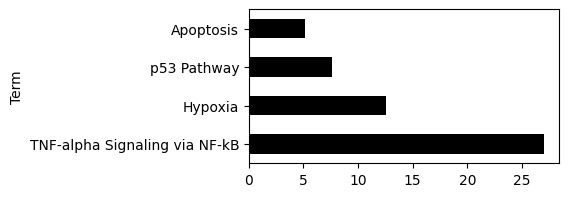

/tmp/ipykernel_1461713/2040025650.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  (-np.log10(Abb.loc['MSigDB_Hallmark_2020',4,'bot'].iloc[:10][['Term','Adjusted P-value']].set_index('Term')['Adjusted P-value'])).plot.barh(color = 'black')


<Axes: ylabel='Term'>

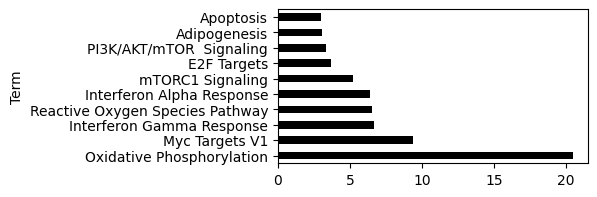

In [202]:
plt.figure(figsize = (4,2) )
(-np.log10(Abb.loc['MSigDB_Hallmark_2020',4,'top'].iloc[:5].iloc[:4][['Term','Adjusted P-value']].set_index('Term')['Adjusted P-value'])).plot.barh(color = 'black')
plt.show()
plt.figure(figsize = (4,2) )
(-np.log10(Abb.loc['MSigDB_Hallmark_2020',4,'bot'].iloc[:10][['Term','Adjusted P-value']].set_index('Term')['Adjusted P-value'])).plot.barh(color = 'black')

/tmp/ipykernel_1461713/2029997983.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  (-np.log10(Abb.loc['MSigDB_Hallmark_2020',4,'bot'].iloc[:10][['Term','Adjusted P-value']].set_index('Term')['Adjusted P-value'])).plot.barh(color = 'black')


<Axes: ylabel='Term'>

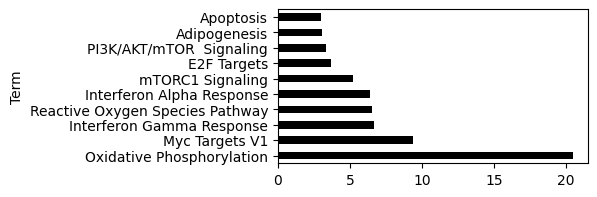

In [40]:
v_plus = pd.Series({'Oxidative Phosphorylation': 5e-20, 'Myc Targets': 4e-10, 'Reactive Oxygen Species pathway': 4e-7, 'Interferon gamma response': 4e-5})
v_minus = pd.Series({'TNF-alpha signaling via NF-KB' : 6e-32, 'Hypoxia': 1e-16, 'UV response':9e-8,  'Apoptosis': 9e-8, 'p53 pathway': 1e-7})


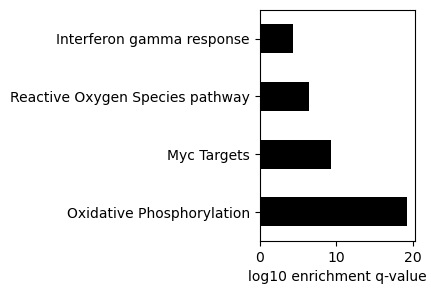

Text(0.5, 0, 'log10 enrichment q-value')

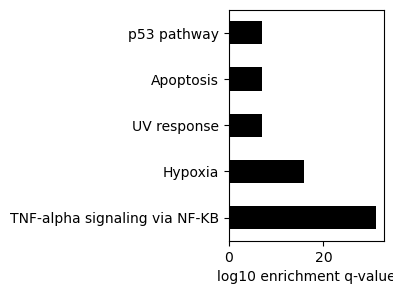

In [65]:

plt.figure(figsize = (2,3))
(-np.log10(v_plus)).plot.barh(color = 'black')
plt.xlabel('log10 enrichment q-value')
plt.show()
plt.figure(figsize = (2,3))
(-np.log10(v_minus)).plot.barh(color = 'black')
plt.xlabel('log10 enrichment q-value')